# 🍷 Práctica 1 — Clasificación de Vinos con Árbol de Decisión
**Machine Learning · ISTER 2026 · Sistemas y Gestión de Data**

---
### Instrucciones
- Las celdas marcadas con `# 🔧 TU CÓDIGO` debes completarlas tú.
- Las celdas sin esa marca ya están dadas — solo ejecútalas.
- Responde las preguntas ❓ haciendo doble clic en la celda de texto.
- Al terminar: **Archivo → Descargar → Descargar .ipynb**

**Nombre:** `[Jostyn Cumbajin]`

**Fecha:** `[8/05/2026]`

## ⚙️ Parte 0 — Setup (solo ejecutar)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets        import load_wine
from sklearn.tree            import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics         import accuracy_score, classification_report

print('✅ Librerías cargadas')

✅ Librerías cargadas


## 🔍 Parte 1 — Exploración del Dataset Wine

In [2]:
# Celda dada — solo ejecuta
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='cultivar')
print(data.DESCR[:600])

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== =====


In [7]:
# 🔧 TU CÓDIGO

# 1. Imprimir número de filas y columnas usando .shape
print(f"Número de filas: {X.shape[0]}")
print(f"Número de columnas: {X.shape[1]}")

# 2. Imprimir los nombres de las variables (columnas)
print("\nNombres de las variables:")
print(X.columns.tolist())

# 3. Distribución de clases con value_counts()
print("\nDistribución de clases (cultivares):")
print(y.value_counts())

Número de filas: 178
Número de columnas: 13

Nombres de las variables:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Distribución de clases (cultivares):
cultivar
1    71
0    59
2    48
Name: count, dtype: int64


❓ **1.1** ¿Cuántas filas y columnas tiene el dataset? ¿Las clases están balanceadas?

*Escribe tu respuesta aquí*

In [8]:
# 🔧 TU CÓDIGO

# 1. Agrega columna 'cultivar' al DataFrame X
X['cultivar'] = y

# 2. Calcula la media por cultivar, redondeada a 2 decimales
medias_por_cultivar = X.groupby('cultivar').mean().round(2)

# (Opcional) Imprimimos el resultado para que puedas verlo
print("Media de cada característica según el tipo de vino (cultivar):")
print(medias_por_cultivar)

# 3. Luego elimina la columna 'cultivar'
X.drop(columns=['cultivar'], inplace=True)

Media de cada característica según el tipo de vino (cultivar):
          alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  \
cultivar                                                            
0           13.74        2.01  2.46              17.04     106.34   
1           12.28        1.93  2.24              20.24      94.55   
2           13.15        3.33  2.44              21.42      99.31   

          total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
cultivar                                                                     
0                  2.84        2.98                  0.29             1.90   
1                  2.26        2.08                  0.36             1.63   
2                  1.68        0.78                  0.45             1.15   

          color_intensity   hue  od280/od315_of_diluted_wines  proline  
cultivar                                                                
0                    5.53  1.06                       

❓ **1.2** ¿Qué variable tiene la mayor diferencia entre cultivares? ¿Por qué sería útil para el árbol?

*Escribe tu respuesta aquí*

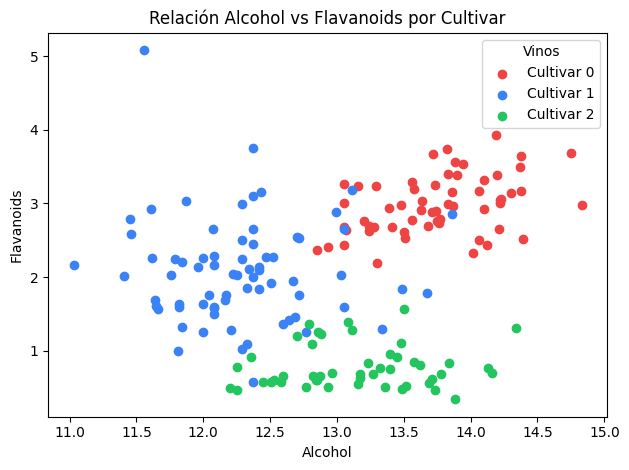

In [10]:
import matplotlib.pyplot as plt

for i in range(3):
    plt.scatter(X.iloc[(y == i).values, 0], X.iloc[(y == i).values, 6], c=colores[i], label=f'Cultivar {i}')

plt.xlabel('Alcohol')
plt.ylabel('Flavanoids')
plt.title('Relación Alcohol vs Flavanoids por Cultivar')
plt.legend(title='Vinos')

plt.tight_layout()
plt.show()

## 🌳 Parte 2 — Preparar Datos y Entrenar el Árbol

In [11]:
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.25, random_state=42)

print(f'Entrenamiento: {len(X_train)} ejemplos')
print(f'Prueba:         {len(X_test)} ejemplos')

Entrenamiento: 133 ejemplos
Prueba:         45 ejemplos


In [12]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
model.fit(X_train, y_train)

print('Modelo entrenado ✅')

Modelo entrenado ✅


In [13]:
from sklearn.metrics import classification_report

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f'Accuracy entrenamiento: {train_acc:.4f}')
print(f'Accuracy prueba: {test_acc:.4f}')

y_pred = model.predict(X_test)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Accuracy entrenamiento: 1.0000
Accuracy prueba: 0.9556

Reporte de Clasificación:
              precision    recall  f1-score   support

     class_0       0.93      0.93      0.93        15
     class_1       0.95      1.00      0.97        18
     class_2       1.00      0.92      0.96        12

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.95        45
weighted avg       0.96      0.96      0.96        45



❓ **2.1** ¿Cuál es la diferencia entre accuracy de entrenamiento y prueba? ¿Hay overfitting?

*Escribe tu respuesta aquí*

## 📊 Parte 3 — Encontrar el max_depth Óptimo

In [15]:
profundidades = [1, 2, 3, 4, 5, 6, 10, None]
resultados = []

for depth in profundidades:
    model_depth = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model_depth.fit(X_train, y_train)

    resultados.append({
        'max_depth': depth,
        'train_accuracy': model_depth.score(X_train, y_train),
        'test_accuracy': model_depth.score(X_test, y_test)
    })

print(pd.DataFrame(resultados).to_string(index=False))

 max_depth  train_accuracy  test_accuracy
       1.0        0.661654       0.600000
       2.0        0.939850       0.866667
       3.0        0.992481       0.955556
       4.0        1.000000       0.955556
       5.0        1.000000       0.955556
       6.0        1.000000       0.955556
      10.0        1.000000       0.955556
       NaN        1.000000       0.955556


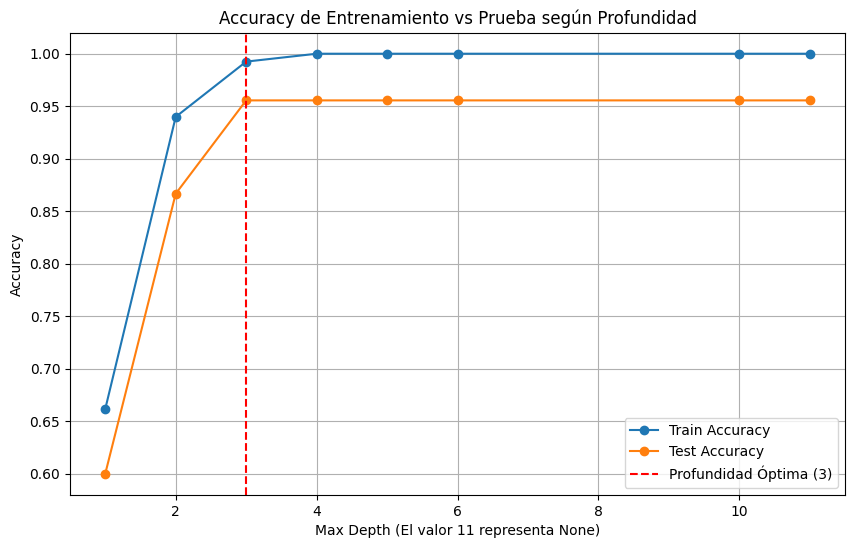

In [16]:
import matplotlib.pyplot as plt

df_res = pd.DataFrame(resultados)
df_res['max_depth_num'] = df_res['max_depth'].fillna(11)

plt.figure(figsize=(10, 6))
plt.plot(df_res['max_depth_num'], df_res['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(df_res['max_depth_num'], df_res['test_accuracy'], marker='o', label='Test Accuracy')
plt.axvline(x=3, color='red', linestyle='--', label='Profundidad Óptima (3)')

plt.title('Accuracy de Entrenamiento vs Prueba según Profundidad')
plt.xlabel('Max Depth (El valor 11 representa None)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

❓ **3.1** ¿Cuál es el max_depth óptimo? ¿A partir de qué valor empieza el overfitting?

*Escribe tu respuesta aquí*

In [ ]:
# 🔧 TU CÓDIGO
# Entrena dos modelos con tu max_depth óptimo:
# uno con criterion='gini' y otro con criterion='entropy'
# Compara e imprime el test accuracy de cada uno

# ___ tu código aquí ___

## 🖼️ Parte 4 — Visualizar el Árbol Óptimo

In [ ]:
# 🔧 TU CÓDIGO
# Entrena el modelo final con el max_depth óptimo
# Visualízalo con plot_tree (filled, rounded, impurity, feature_names, class_names)

model_final = DecisionTreeClassifier(max_depth=___, criterion='gini', random_state=42)
model_final.fit(___, ___)

plt.figure(figsize=(18, 8))
# ___ plot_tree aquí ___
plt.title('___')
plt.tight_layout()
plt.show()

In [ ]:
# 🔧 TU CÓDIGO
# Imprime el árbol en texto con export_text
# Crea un pd.Series con feature_importances_, ordénalo de mayor a menor
# Imprime los resultados y genera un gráfico de barras horizontales

# ___ tu código aquí ___

❓ **4.1** ¿Cuál es la variable del nodo raíz? ¿Cuáles son las 3 variables más importantes?

*Escribe tu respuesta aquí*

## 🧮 Parte 5 — Calcular Gini del Nodo Raíz

In [ ]:
# Celda dada
clases, conteos = np.unique(y_train, return_counts=True)
total = len(y_train)
for c, n in zip(data.target_names, conteos):
    print(f'  {c}: {n} ejemplos  →  p = {n/total:.4f}')

In [ ]:
# 🔧 TU CÓDIGO
# 1. Calcula las proporciones
# 2. Aplica Gini = 1 - Σ(pᵢ²)
# 3. Obtén el Gini de sklearn: model_final.tree_.impurity[0]
# 4. Compara e imprime si coinciden

# ___ tu código aquí ___

❓ **5.1** ¿Coinciden el Gini manual y el de sklearn?

*Escribe tu respuesta aquí*

## 🏆 Desafío Bonus (opcional)
Escribe una función `encontrar_mejor_depth(dataset, profundidades, test_size)` que reciba cualquier dataset de sklearn y retorne automáticamente el mejor max_depth.

In [ ]:
# 🔧 DESAFÍO
def encontrar_mejor_depth(dataset, profundidades=None, test_size=0.25):
    if profundidades is None:
        profundidades = [1, 2, 3, 4, 5, 6, 8, 10]
    # ___ tu código aquí ___
    pass

mejor, df = encontrar_mejor_depth(load_wine())
print(f'Mejor max_depth: {mejor}')
print(df)

## ✅ Conclusiones

Responde:
1. ¿Cuál fue el max_depth óptimo y por qué?
2. ¿Qué variable química resultó más importante?
3. ¿Qué diferencia notaste entre Gini y Entropía en este dataset?

*Escribe tus conclusiones aquí*